In [37]:
# Volcano plot — PBS noise cells (Normal vs ER+ tumour)

# Identify differentially expressed genes in potential biological signal (PBS) noise
# cells from Normal and ER+ tumour specimens, and highlight genes linked to current
# ER+ breast cancer treatments.

## 0. Initializations
# -- imports --
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

from collections import defaultdict

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [38]:
# -- datasets --
gse = GSE161529()

In [39]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.85, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.25, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=None, q_high=0.3, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=0.95, q_high=None, q_mod_low=None, q_mod_high=None),
)

In [40]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [41]:
FOCUS_SUBTYPES = ["Normal", "ER+ tumour"]
MIN_CELLS_PER_SUBJECT = 50

adatas_to_merge = []
for subtype in FOCUS_SUBTYPES:
    for adata in subtype_to_adata[subtype].values():
        if adata.n_obs < MIN_CELLS_PER_SUBJECT:
            continue
        adata_copy = adata.copy()
        adata_copy.obs["cancer_type"] = adata_copy.uns["cancer_type"]
        adatas_to_merge.append(adata_copy)

pbs_focus = ad.concat(adatas_to_merge, join="inner")
pbs_focus.obs_names_make_unique()
if not sp.issparse(pbs_focus.X):
    pbs_focus.X = sp.csr_matrix(pbs_focus.X)

pbs_focus.obs["cancer_type"].value_counts()

C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


cancer_type
ER+ tumour    1357
Normal         752
Name: count, dtype: int64

In [42]:
sc.pp.normalize_total(pbs_focus)
sc.pp.log1p(pbs_focus)

sc.tl.rank_genes_groups(
    pbs_focus,
    groupby="cancer_type",
    groups=["ER+ tumour"],
    reference="Normal",
    method="wilcoxon",
    n_genes=pbs_focus.n_vars,
)

de_results = pbs_focus.uns["rank_genes_groups"]
de_df = pd.DataFrame({
    "gene": de_results["names"]["ER+ tumour"],
    "log2fc": de_results["logfoldchanges"]["ER+ tumour"],
    "pval": de_results["pvals"]["ER+ tumour"],
    "score": de_results["scores"]["ER+ tumour"],
})
de_df = de_df.dropna().drop_duplicates(subset="gene")
de_df["neg_log10_padj"] = -np.log10(de_df["pval"].clip(lower=1e-300))
de_df.head(10)

,gene,log2fc,pval,score,neg_log10_padj
0,MALAT1,2.864486,6.626381e-99,21.108631,98.178724
1,TMSB4X,1.935278,2.193005e-66,17.211081,65.658960
2,COX6C,3.919183,6.605176e-63,16.740837,62.180116
3,KRT19,3.009318,3.681229e-44,13.938791,43.434007
4,MT-CO2,1.248346,4.288366e-41,13.425473,40.367708
5,MT-CO1,1.159696,1.232060e-38,12.999462,37.909368
6,B2M,1.271004,7.782601e-38,12.857733,37.108875
7,SERF2,1.582527,5.189002e-37,12.710217,36.284916
8,RPL41,0.940183,1.011405e-36,12.657923,35.995075
9,SCGB2A2,5.692261,4.047418e-31,11.601538,30.392822


In [43]:
# Established ER+ breast cancer therapy targets
ESTABLISHED_TREATMENT_GENES = {
    "Endocrine (SERD/SERM)": ["ESR1", "PGR", "GREB1", "TFF1", "GATA3", "XBP1"],
    "Aromatase inhibitor": ["CYP19A1"],
    "CDK4/6 inhibitor": ["CDK4", "CDK6", "CCND1"],
    "PI3K/AKT/mTOR": ["PIK3CA", "AKT1", "MTOR", "PTEN", "TSC1"],
    "PARP inhibitor": ["BRCA1", "BRCA2", "PARP1"],
    "Proliferation / chemo": ["MKI67", "TOP2A", "BCL2", "MYC"],
}

# Novel / emerging targets in active clinical or preclinical development
NOVEL_TREATMENT_GENES = {
    "AKT inhibitor (capivasertib)": ["AKT2", "AKT3"],
    "ADC — TROP2 (Dato-DXd, sacituzumab)": ["TACSTD2"],
    "ADC — HER2 / HER3 (T-DXd, patritumab)": ["ERBB2", "ERBB3"],
    "ADC — B7-H4 / LIV-1": ["VTCN1", "SLC39A6"],
    "CDK2 inhibitor (post–CDK4/6 resistance)": ["CDK2", "CCNE1"],
    "KAT6 epigenetic inhibitor (PF-07248144)": ["KAT6A", "KAT6B"],
    "ESR1 degrader / co-regulator (PROTAC, next-gen SERD)": ["NCOA3", "NCOR1"],
    "FGFR inhibitor (FGFR1-amp ER+)": ["FGFR1", "FGFR2"],
    "MDM2–p53 axis": ["MDM2", "TP53"],
    "RANKL (bone-modifying)": ["TNFSF11", "TNFRSF11A"],
    "Immune checkpoint (trials in ER+)": ["CD274", "PDCD1"],
}

# ER+ subtype–specific targets (established or novel); highlighted separately on plots
ER_PLUS_SPECIFIC_GENES = {
    "Luminal / endocrine": ["ESR1", "PGR", "GREB1", "TFF1", "GATA3", "XBP1", "FOXA1", "SPDEF", "AGR2"],
    "Aromatase inhibitor": ["CYP19A1"],
    "CDK4/6 inhibitor": ["CDK4", "CDK6", "CCND1"],
    "PI3K/AKT (ER+ enriched)": ["PIK3CA", "AKT1", "AKT2", "AKT3"],
    "ER+ ADC": ["TACSTD2", "ERBB2", "ERBB3", "SLC39A6"],
    "KAT6 epigenetic (ER+ trials)": ["KAT6A", "KAT6B"],
    "ESR1 degrader / co-regulator": ["NCOA3", "NCOR1"],
    "Proliferation biomarker": ["MKI67"],
}

treatment_gene_to_class = {}
for gene_map in (ESTABLISHED_TREATMENT_GENES, NOVEL_TREATMENT_GENES):
    for drug_class, genes in gene_map.items():
        for gene in genes:
            treatment_gene_to_class[gene] = drug_class

er_plus_gene_to_class = {
    gene: drug_class
    for drug_class, genes in ER_PLUS_SPECIFIC_GENES.items()
    for gene in genes
}

ESTABLISHED_GENE_SET = {
    gene for genes in ESTABLISHED_TREATMENT_GENES.values() for gene in genes
}
NOVEL_GENE_SET = {
    gene for genes in NOVEL_TREATMENT_GENES.values() for gene in genes
}
ER_PLUS_SPECIFIC_GENE_SET = {
    gene for genes in ER_PLUS_SPECIFIC_GENES.values() for gene in genes
}
NOVEL_ONLY_GENE_SET = NOVEL_GENE_SET - ESTABLISHED_GENE_SET
TREATMENT_GENE_SET = ESTABLISHED_GENE_SET | NOVEL_GENE_SET | ER_PLUS_SPECIFIC_GENE_SET

In [44]:
from matplotlib.lines import Line2D

# Michigan / colorblind-safe palette (matches 08-a, 10-a)
MI_PALETTE = [
    "#000000",  # black
    "#0072B2",  # blue
    "#009E73",  # bluish green
    "#56B4E9",  # sky blue
    "#CC79A7",  # reddish purple
    "#E69F00",  # yellow-orange
    "#D55E00",  # vermillion
]
MI_FONT_COLOR = "#00274C"
MI_COLOR_NS = "#56B4E9"
MI_COLOR_SIG = MI_PALETTE[1]
MI_COLOR_ESTABLISHED = MI_PALETTE[6]
MI_COLOR_ER_PLUS = MI_PALETTE[2]
MI_COLOR_NOVEL = MI_PALETTE[4]

sns.set_palette(MI_PALETTE)
plt.rcParams.update({
    "text.color": MI_FONT_COLOR,
    "axes.labelcolor": MI_FONT_COLOR,
    "axes.edgecolor": MI_FONT_COLOR,
    "xtick.labelcolor": MI_FONT_COLOR,
    "ytick.labelcolor": MI_FONT_COLOR,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})


def apply_michigan_style(ax: plt.Axes, fig: plt.Figure | None = None) -> None:
    if fig is not None:
        fig.patch.set_facecolor("none")
    ax.set_facecolor("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color(MI_FONT_COLOR)
    ax.spines["left"].set_color(MI_FONT_COLOR)


def plot_volcano(
    de_df: pd.DataFrame,
    *,
    log2fc_col: str = "log2fc",
    pval_col: str = "neg_log10_padj",
    label_genes: set[str] | None = None,
    novel_genes: set[str] | None = None,
    er_plus_genes: set[str] | None = None,
    log2fc_threshold: float = 0.5,
    pval_threshold: float = 1.3,
    title: str = "",
    ax: plt.Axes | None = None,
    show_legend: bool = True,
    xlim: tuple[float, float] | None = (-8, 8),
    label_only_significant: bool = True,
) -> plt.Axes:
    """Volcano plot for differential expression results."""
    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.get_figure()
    apply_michigan_style(ax, fig)

    all_targets = (label_genes or set()) | (novel_genes or set()) | (er_plus_genes or set())
    er_plus = er_plus_genes or set()
    novel_only = (novel_genes or set()) - er_plus

    is_sig = (
        (de_df[pval_col] >= pval_threshold)
        & (de_df[log2fc_col].abs() >= log2fc_threshold)
    )
    is_target = de_df["gene"].isin(all_targets)
    is_label = is_target.copy()
    if label_only_significant:
        is_label = is_label & is_sig

    base = de_df[~is_sig & ~is_target]
    sig = de_df[is_sig & ~is_target]
    labeled = de_df[is_label]

    def _target_color(gene: str) -> str:
        if gene in er_plus:
            return MI_COLOR_ER_PLUS
        if gene in novel_only:
            return MI_COLOR_NOVEL
        return MI_COLOR_ESTABLISHED

    ax.scatter(
        base[log2fc_col], base[pval_col],
        c=MI_COLOR_NS, s=8, alpha=0.35, linewidths=0,
    )
    ax.scatter(
        sig[log2fc_col], sig[pval_col],
        c=MI_COLOR_SIG, s=12, alpha=0.7, linewidths=0,
    )

    for gene, group in de_df[is_target & ~is_label].groupby("gene"):
        ax.scatter(
            group[log2fc_col], group[pval_col],
            c=_target_color(gene), s=30, alpha=0.6,
            linewidths=0.5, edgecolors=MI_FONT_COLOR,
        )

    for gene, group in labeled.groupby("gene"):
        ax.scatter(
            group[log2fc_col], group[pval_col],
            c=_target_color(gene), s=40, alpha=0.9,
            linewidths=0.5, edgecolors=MI_FONT_COLOR,
        )

    for _, row in labeled.iterrows():
        ax.annotate(
            row["gene"],
            (row[log2fc_col], row[pval_col]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=10,
            color=MI_FONT_COLOR,
        )

    ax.axvline(log2fc_threshold, color=MI_FONT_COLOR, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axvline(-log2fc_threshold, color=MI_FONT_COLOR, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(pval_threshold, color=MI_FONT_COLOR, linestyle="--", linewidth=0.8, alpha=0.5)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.set_xlabel("log2 fold change (ER+ tumour vs Normal)")
    ax.set_ylabel(r"$-\log_{10}$(p-value)")
    ax.set_title(title)

    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0], marker="o", color="w", markerfacecolor=MI_COLOR_NS,
                markersize=6, alpha=0.6, label="Not significant",
            ),
            Line2D(
                [0], [0], marker="o", color="w", markerfacecolor=MI_COLOR_SIG,
                markersize=6, label="Significant",
            ),
            Line2D(
                [0], [0], marker="o", color="w", markerfacecolor=MI_COLOR_ER_PLUS,
                markeredgecolor=MI_FONT_COLOR, markersize=8, label="ER+ specific target",
            ),
            Line2D(
                [0], [0], marker="o", color="w", markerfacecolor=MI_COLOR_ESTABLISHED,
                markeredgecolor=MI_FONT_COLOR, markersize=8, label="Established target",
            ),
            Line2D(
                [0], [0], marker="o", color="w", markerfacecolor=MI_COLOR_NOVEL,
                markeredgecolor=MI_FONT_COLOR, markersize=8, label="Novel target",
            ),
        ]
        ax.legend(
            handles=legend_handles,
            loc="upper right",
            framealpha=0.95,
            facecolor="white",
            edgecolor=MI_FONT_COLOR,
        )

    return ax

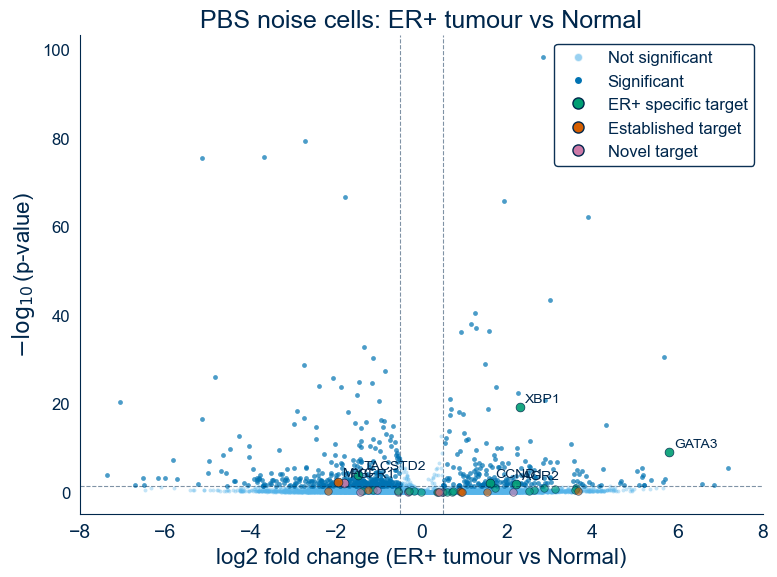

In [45]:
plot_volcano(
    de_df,
    label_genes=TREATMENT_GENE_SET,
    novel_genes=NOVEL_ONLY_GENE_SET,
    er_plus_genes=ER_PLUS_SPECIFIC_GENE_SET,
    title="PBS noise cells: ER+ tumour vs Normal",
)
plt.tight_layout()
plt.show()

In [46]:
def classify_target_type(gene: str) -> str:
    if gene in ER_PLUS_SPECIFIC_GENE_SET:
        return "ER+ specific"
    if gene in NOVEL_ONLY_GENE_SET:
        return "Novel"
    return "Established"


treatment_hits = de_df[de_df["gene"].isin(TREATMENT_GENE_SET)].copy()
treatment_hits["target_type"] = treatment_hits["gene"].map(classify_target_type)
treatment_hits["therapy_class"] = treatment_hits["gene"].map(treatment_gene_to_class)
treatment_hits["er_plus_class"] = treatment_hits["gene"].map(er_plus_gene_to_class)
treatment_hits = treatment_hits.sort_values("neg_log10_padj", ascending=False)
treatment_hits[
    ["gene", "target_type", "er_plus_class", "therapy_class", "log2fc", "pval", "neg_log10_padj"]
]

,gene,target_type,er_plus_class,therapy_class,log2fc,pval,neg_log10_padj
15,XBP1,ER+ specific,Luminal / endocrine,Endocrine (SERD/SERM),2.304440,8.613988e-20,19.064796
37,GATA3,ER+ specific,Luminal / endocrine,Endocrine (SERD/SERM),5.795280,1.140118e-09,8.943050
33407,TACSTD2,ER+ specific,ER+ ADC,"ADC — TROP2 (Dato-DXd, sacituzumab)",-1.488803,1.557683e-04,3.807521
33302,MYC,Established,NaN,Proliferation / chemo,-1.962399,4.844411e-03,2.314759
33277,FGFR1,Novel,NaN,FGFR inhibitor (FGFR1-amp ER+),-1.803662,7.800656e-03,2.107869
163,CCND1,ER+ specific,CDK4/6 inhibitor,CDK4/6 inhibitor,1.612562,8.234793e-03,2.084347
188,AGR2,ER+ specific,Luminal / endocrine,NaN,2.213105,2.110792e-02,1.675555
296,ESR1,ER+ specific,Luminal / endocrine,Endocrine (SERD/SERM),3.629345,1.221405e-01,0.913140
310,TFF1,ER+ specific,Luminal / endocrine,Endocrine (SERD/SERM),1.731866,1.328582e-01,0.876612
311,SPDEF,ER+ specific,Luminal / endocrine,NaN,2.872434,1.338042e-01,0.873530


C:\Users\silly\miniconda3\envs\signals-in-the-noise\Lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


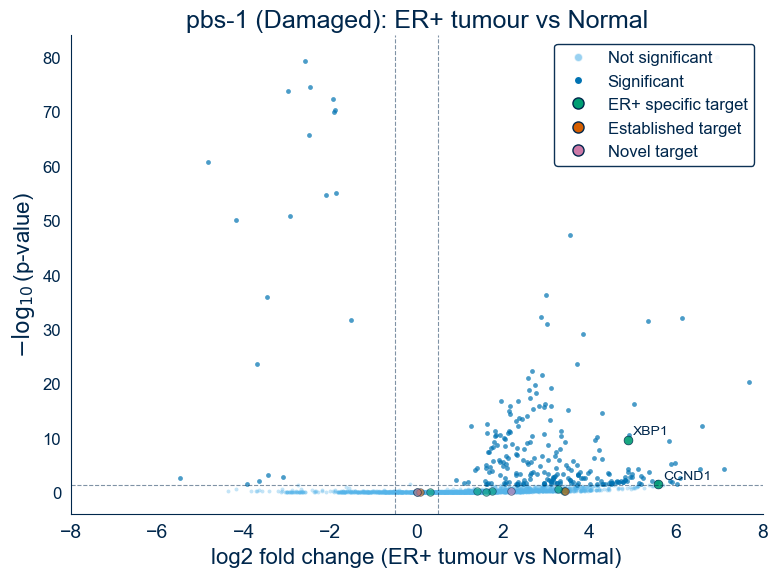

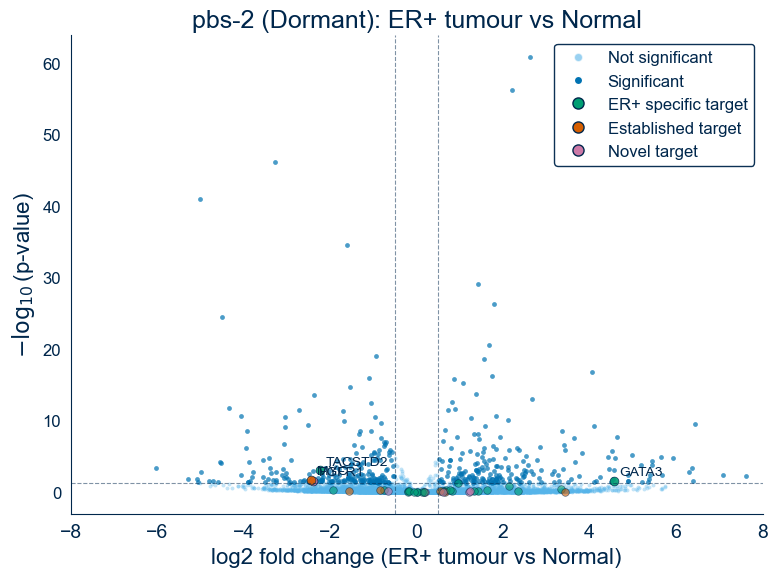

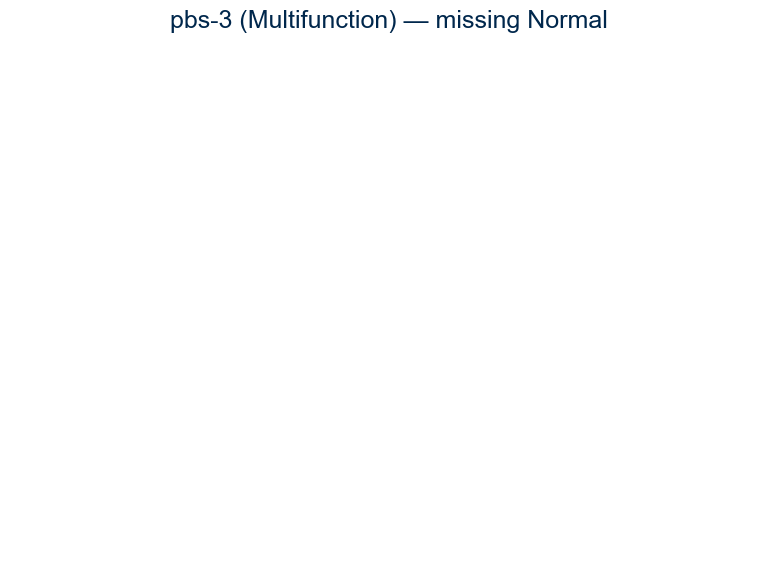

In [47]:
PBS_NAMES = {
    "pbs-1": "Damaged",
    "pbs-2": "Dormant",
    "pbs-3": "Multifunction",
}


def de_df_for_pbs(pbs_label: str) -> pd.DataFrame | None:
    adatas_pbs = []
    for subtype in FOCUS_SUBTYPES:
        for adata in subtype_to_adata[subtype].values():
            if adata.n_obs < MIN_CELLS_PER_SUBJECT:
                continue
            adata_pbs = adata[adata.obs["pbs"] == pbs_label].copy()
            if adata_pbs.n_obs == 0:
                continue
            adata_pbs.obs["cancer_type"] = adata_pbs.uns["cancer_type"]
            adatas_pbs.append(adata_pbs)

    if not adatas_pbs:
        return None

    pbs_adata = ad.concat(adatas_pbs, join="inner")
    pbs_adata.obs_names_make_unique()
    if not sp.issparse(pbs_adata.X):
        pbs_adata.X = sp.csr_matrix(pbs_adata.X)

    present_types = set(pbs_adata.obs["cancer_type"].astype(str).unique())
    if not set(FOCUS_SUBTYPES).issubset(present_types):
        return None

    sc.pp.normalize_total(pbs_adata)
    sc.pp.log1p(pbs_adata)
    sc.tl.rank_genes_groups(
        pbs_adata,
        groupby="cancer_type",
        groups=["ER+ tumour"],
        reference="Normal",
        method="wilcoxon",
        n_genes=pbs_adata.n_vars,
    )

    pbs_de = pbs_adata.uns["rank_genes_groups"]
    pbs_df = pd.DataFrame({
        "gene": pbs_de["names"]["ER+ tumour"],
        "log2fc": pbs_de["logfoldchanges"]["ER+ tumour"],
        "pval": pbs_de["pvals"]["ER+ tumour"],
    })
    pbs_df = pbs_df.dropna().drop_duplicates(subset="gene")
    pbs_df["neg_log10_padj"] = -np.log10(pbs_df["pval"].clip(lower=1e-300))
    return pbs_df


for pbs_label, pbs_name in PBS_NAMES.items():
    pbs_df = de_df_for_pbs(pbs_label)
    fig, ax = plt.subplots(figsize=(8, 6))

    if pbs_df is None:
        apply_michigan_style(ax, fig)
        subjects_with_cells = [
            adata
            for subtype in FOCUS_SUBTYPES
            for adata in subtype_to_adata[subtype].values()
            if adata.n_obs >= MIN_CELLS_PER_SUBJECT
            and adata[adata.obs["pbs"] == pbs_label].n_obs > 0
        ]
        if not subjects_with_cells:
            reason = "no cells"
        else:
            present = {str(adata.uns["cancer_type"]) for adata in subjects_with_cells}
            missing = set(FOCUS_SUBTYPES) - present
            reason = f"missing {', '.join(sorted(missing))}"
        ax.set_title(f"{pbs_label} ({pbs_name}) — {reason}")
        ax.axis("off")
    else:
        plot_volcano(
            pbs_df,
            label_genes=TREATMENT_GENE_SET,
            novel_genes=NOVEL_ONLY_GENE_SET,
            er_plus_genes=ER_PLUS_SPECIFIC_GENE_SET,
            title=f"{pbs_label} ({pbs_name}): ER+ tumour vs Normal",
            ax=ax,
        )

    plt.tight_layout()
    plt.show()